In [359]:
import sys
sys.path.append('../')
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from utils import *  #only needed for xgboost
import xgboost as xgb
from baselines import *

In [360]:
predictor_columns = [str(i) for i in range(3, 26)]
target_column = 'estimated_volume'

In [361]:
data = pd.read_csv('datasets/stem_data.csv', index_col = [0])
data_source = data[data['Species'] == 'Pine']
data_target = data[data['Species'] == 'Spruce']
print(f'source dataset size: {len(data_source)}, target dataset size: {len(data_target)}')

data_temp, data_test = train_test_split(data_target, test_size=0.1, random_state=13)
data_train, data_val = train_test_split(data_temp, test_size=0.1, random_state=1)

print(f'train (target) dataset size: {len(data_train)}, val (target) dataset size: {len(data_val)}, test (target) dataset size: {len(data_test)}')


source dataset size: 197, target dataset size: 113
train (target) dataset size: 90, val (target) dataset size: 11, test (target) dataset size: 12


In [362]:
X_source_train = np.array(data_source[predictor_columns])
y_source_train = np.array(data_source[target_column]) #change this to "Dgv" to use diameter as source label!

#Specific train and test set
X_target_train = np.array(data_train[predictor_columns])
y_target_train = np.array(data_train[target_column])

X_target_val = np.array(data_val[predictor_columns])
y_target_val = np.array(data_val[target_column])

X_target_test = np.array(data_test[predictor_columns])
y_target_test = np.array(data_test[target_column])

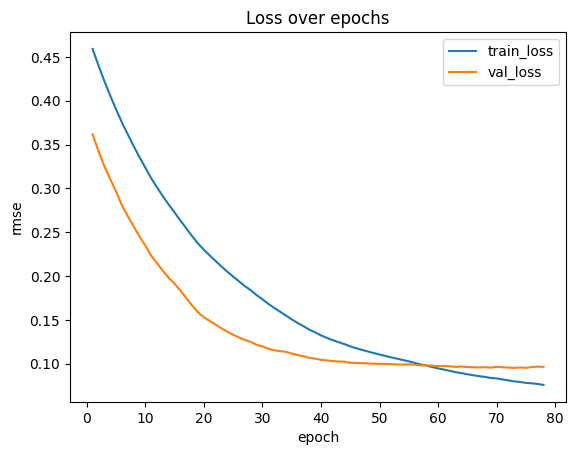

12.83340023448968


In [367]:
fiter = MTransferTreeBoost()
fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=5, show_curves = True)
rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')

print((rmse / np.mean(y_target_test))*100)

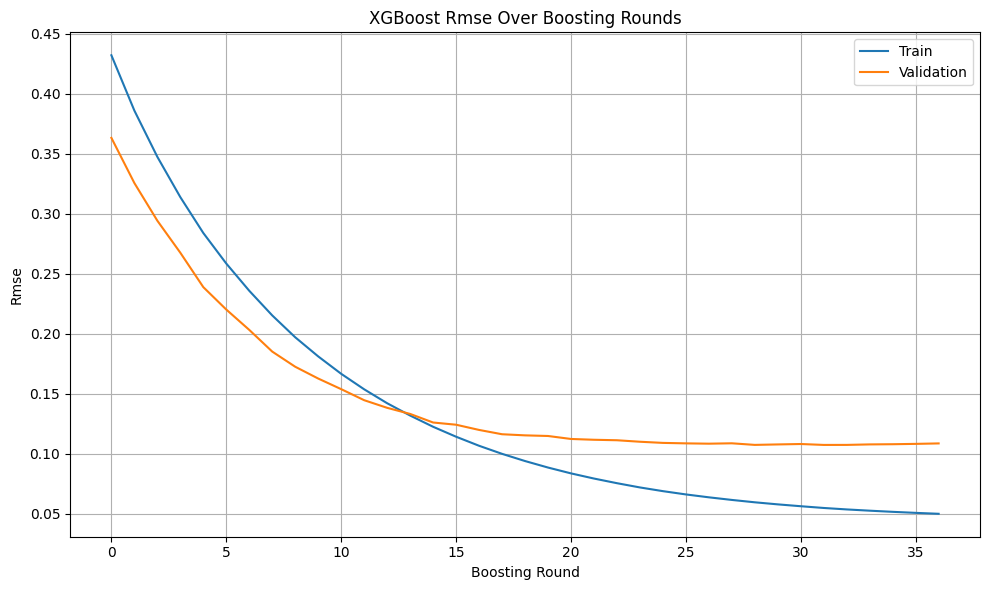

15.712531596840925


In [364]:
params = {
    'objective': 'reg:pseudohubererror',  # Regression with squared error
    'max_depth': 2,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
bst = train_xgboost(X_target_train, y_target_train, X_target_val, y_target_val, boosting_rounds=100, params=params, early_stopping_rounds=5, show_curve=True)
preds = test_xgboost(X_target_test, bst)
val_preds = test_xgboost(X_target_val, bst)
val_rmse = compute_rmse(val_preds, y_target_val)
val_mae = compute_mae(val_preds, y_target_val)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)

print((rmse / np.mean(y_target_test))*100)

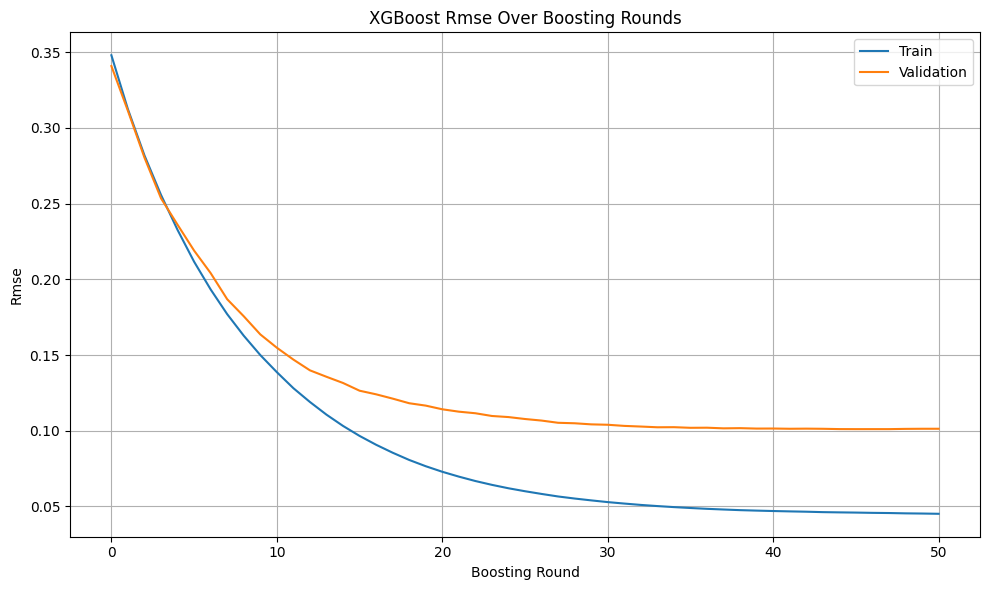

15.37853721586138


In [365]:
#additional source/target dummy sets for naive xgboost
ones = np.ones((len(X_target_train), 1))
X_target_train_with_dummy = np.hstack((X_target_train.copy(), ones))
ones = np.ones((len(X_target_val), 1))
X_target_val_with_dummy = np.hstack((X_target_val.copy(), ones))
ones = np.ones((len(X_target_test), 1))
X_target_test_with_dummy= np.hstack((X_target_test.copy(), ones))

zeros = np.zeros((len(X_source_train), 1))
X_source_train_with_dummy = np.hstack((X_source_train.copy(), zeros))

X_comb = np.concatenate((X_target_train_with_dummy, X_source_train_with_dummy)) 
y_comb = np.concatenate((y_target_train, y_source_train))       
bst = train_xgboost(X_comb, y_comb, X_target_val_with_dummy, y_target_val, boosting_rounds=100, params=params, early_stopping_rounds=5, show_curve=True)
preds = test_xgboost(X_target_test_with_dummy, bst)
val_preds = test_xgboost(X_target_val_with_dummy, bst)
val_rmse = compute_rmse(val_preds, y_target_val)
val_mae = compute_mae(val_preds, y_target_val)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)
print((rmse / np.mean(y_target_test))*100)